In [1]:
from pathlib import Path
import os
import pandas as pd

# Define the Excel file path and worksheet name.
PROJECT_ROOT = os.path.abspath("../..")
CASE_ID = 'C0004'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_DIR = os.path.join(PROJECT_ROOT, 'data', CASE_ID) # Read the data file JUST output by the scan script

data_file = os.path.join(DATA_DIR, 'C0004R01_PARK25_AC_1D_SCAN.xlsx')
sheet_name = 'Parameter scan'

# Read the parameter-scan results from the Excel workbook.
data = pd.read_excel(data_file, sheet_name=sheet_name)

# Display the first five rows.
data.head()

,case_id,V_air_m_s,T_air_in_C,s_gap_mm,S_T_mm,P_pump,E_pump_cumulative,Tmax_mission_C,DeltaT_mission_max_C,cruise_recovery_Tmax_C,Tair_out_cruise_end_C,dTmax_takeoff_C,dTmax_climb_C,dTmax_transition1_C,dTmax_cruise_C,dTmax_transition2_C,dTmax_descent_C,dTmax_hover_C,dTmax_landing_C
0,C0004_S001,1.0,20,1,19,0.002397,3.307486,45.352213,3.014238,-3.039507,23.622948,0.419018,1.571987,2.093558,3.039507,0.102903,0.678262,16.823725,0.623252
1,C0004_S002,1.0,20,2,20,0.002641,3.645242,45.223497,2.889696,-2.910790,23.462913,0.419018,1.571987,2.093558,2.910790,0.102903,0.678262,16.823725,0.623252
2,C0004_S003,1.0,20,3,21,0.002898,3.999415,45.104857,2.774856,-2.792151,23.316183,0.419018,1.571987,2.093558,2.792151,0.102903,0.678262,16.823725,0.623252
3,C0004_S004,1.0,20,4,22,0.003167,4.370005,44.995176,2.668649,-2.682469,23.181192,0.419018,1.571987,2.093558,2.682469,0.102903,0.678262,16.823725,0.623252
4,C0004_S005,1.0,20,5,23,0.003447,4.757011,44.893492,2.570154,-2.580785,23.056606,0.419018,1.571987,2.093558,2.580785,0.102903,0.678262,16.823725,0.623252


In [2]:
# Select the columns required for plotting.
plot_data = data[
    [
        'V_air_m_s',
        'T_air_in_C',
        's_gap_mm',
        'Tmax_mission_C',
        'DeltaT_mission_max_C',
        'P_pump',
    ]
].copy()

# Display the selected data.
plot_data.head()

,V_air_m_s,T_air_in_C,s_gap_mm,Tmax_mission_C,DeltaT_mission_max_C,P_pump
0,1.0,20,1,45.352213,3.014238,0.002397
1,1.0,20,2,45.223497,2.889696,0.002641
2,1.0,20,3,45.104857,2.774856,0.002898
3,1.0,20,4,44.995176,2.668649,0.003167
4,1.0,20,5,44.893492,2.570154,0.003447


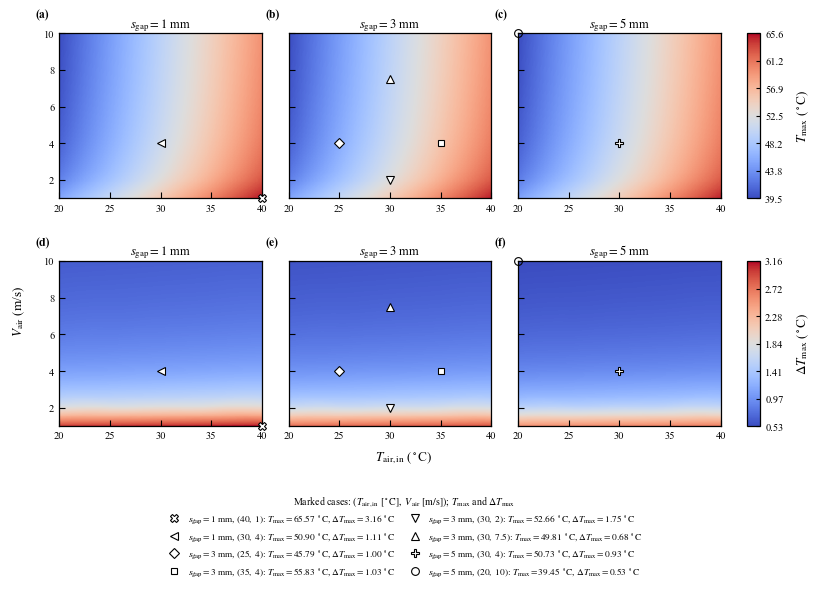

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker
from matplotlib.lines import Line2D
from scipy.interpolate import griddata


# Apply the plotting style used in the original figure.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 8.5,
    'axes.labelsize': 9.5,
    'axes.titlesize': 9.0,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})


# Display only the three representative cell spacings.
gap_values = [1.0, 3.0, 5.0]
panel_labels = [
    ['(a)', '(b)', '(c)'],
    ['(d)', '(e)', '(f)'],
]


# Representative cases selected for the quantitative comparisons, together
# with the global maximum and minimum cases retained from the original figure.
# Coordinates are written as (T_air_in, V_air).  The shared reference point
# at T_air_in = 30 degC, V_air = 4 m/s, and s_gap = 3 mm is intentionally not
# marked, keeping four comparison markers in panel (b).
marker_points = {
    1.0: [
        {
            'x': 40.0, 'y': 1.0, 'marker': 'X', 'size': 5.8,
            'facecolor': 'white',
            'label': r'$(40,\ 1)$',
            'group': 'Global maximum',
        },
        {
            'x': 30.0, 'y': 4.0, 'marker': '<', 'size': 5.2,
            'facecolor': 'white',
            'label': r'$(30,\ 4)$',
            'group': 'Cell-spacing comparison',
        },
    ],
    3.0: [
        {
            'x': 25.0, 'y': 4.0, 'marker': 'D', 'size': 4.8,
            'facecolor': 'white',
            'label': r'$(25,\ 4)$',
            'group': 'Inlet-temperature comparison',
        },
        {
            'x': 35.0, 'y': 4.0, 'marker': 's', 'size': 4.8,
            'facecolor': 'white',
            'label': r'$(35,\ 4)$',
            'group': 'Inlet-temperature comparison',
        },
        {
            'x': 30.0, 'y': 2.0, 'marker': 'v', 'size': 5.2,
            'facecolor': 'white',
            'label': r'$(30,\ 2)$',
            'group': 'Inlet-velocity comparison',
        },
        {
            'x': 30.0, 'y': 7.5, 'marker': '^', 'size': 5.2,
            'facecolor': 'white',
            'label': r'$(30,\ 7.5)$',
            'group': 'Inlet-velocity comparison',
        },
    ],
    5.0: [
        {
            'x': 30.0, 'y': 4.0, 'marker': 'P', 'size': 5.2,
            'facecolor': 'white',
            'label': r'$(30,\ 4)$',
            'group': 'Cell-spacing comparison',
        },
        {
            'x': 20.0, 'y': 10.0, 'marker': 'o', 'size': 5.6,
            'facecolor': 'none',
            'label': r'$(20,\ 10)$',
            'group': 'Global minimum',
        },
    ],
}


# Use the selected spacings to define one common color range for each response.
selected_data = plot_data[
    plot_data['s_gap_mm'].isin(gap_values)
]

t_max_min = selected_data['Tmax_mission_C'].min()
t_max_max = selected_data['Tmax_mission_C'].max()

delta_t_min = selected_data['DeltaT_mission_max_C'].min()
delta_t_max = selected_data['DeltaT_mission_max_C'].max()


def interpolate_field(gap_data, value_column, value_min, value_max):
    """Interpolate one response variable onto a dense rectangular grid."""
    t_air_in = gap_data['T_air_in_C'].to_numpy()
    v_air = gap_data['V_air_m_s'].to_numpy()
    values = gap_data[value_column].to_numpy()

    t_air_dense = np.linspace(t_air_in.min(), t_air_in.max(), 350)
    v_air_dense = np.linspace(v_air.min(), v_air.max(), 350)

    t_air_grid, v_air_grid = np.meshgrid(t_air_dense, v_air_dense)

    value_grid = griddata(
        (t_air_in, v_air),
        values,
        (t_air_grid, v_air_grid),
        method='cubic',
    )

    # Fill any edge NaNs with nearest-neighbour interpolation.
    if np.isnan(value_grid).any():
        nearest_grid = griddata(
            (t_air_in, v_air),
            values,
            (t_air_grid, v_air_grid),
            method='nearest',
        )
        value_grid = np.where(
            np.isnan(value_grid),
            nearest_grid,
            value_grid,
        )

    # Avoid small interpolation overshoots outside the original data range.
    value_grid = np.clip(value_grid, value_min, value_max)

    return t_air_grid, v_air_grid, value_grid


def add_case_markers(axis, gap_value):
    """Add the discussion-case markers to one subplot."""
    for point in marker_points[gap_value]:
        axis.plot(
            point['x'],
            point['y'],
            marker=point['marker'],
            markersize=point['size'],
            markerfacecolor=point['facecolor'],
            markeredgecolor='black',
            markeredgewidth=0.8,
            linestyle='none',
            clip_on=False,
            zorder=10,
        )


def format_heatmap_axis(axis, gap_value, panel_label, show_y_labels):
    """Apply the unchanged coordinate ranges, ticks, and panel labels."""
    axis.set_title(
        rf'$s_{{\mathrm{{gap}}}}={gap_value:g}$ mm',
        pad=2.5,
    )

    # Place (a)-(f) outside the upper-left corner of each axis frame.
    if panel_label:
        axis.text(
            -0.115,
            1.075,
            panel_label,
            transform=axis.transAxes,
            horizontalalignment='left',
            verticalalignment='bottom',
            fontsize=8.5,
            fontweight='bold',
            color='black',
            clip_on=False,
            zorder=11,
        )

    # Keep the original coordinate ranges and ticks unchanged.
    axis.set_xlim(20, 40)
    axis.set_ylim(1, 10)
    axis.set_xticks([20, 25, 30, 35, 40])
    axis.set_yticks([2, 4, 6, 8, 10])

    if not show_y_labels:
        axis.tick_params(labelleft=False)

    for spine in axis.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('black')


# Create one combined 2 x 3 figure:
# top row: Tmax; bottom row: DeltaTmax.
fig_heatmaps = plt.figure(figsize=(8.2, 6.55))

grid = fig_heatmaps.add_gridspec(
    nrows=2,
    ncols=4,
    width_ratios=[1, 1, 1, 0.065],
    left=0.080,
    right=0.935,
    bottom=0.325,
    top=0.925,
    wspace=0.17,
    hspace=0.38,
)

axes_heatmaps = np.empty((2, 3), dtype=object)
for row in range(2):
    for col in range(3):
        axes_heatmaps[row, col] = fig_heatmaps.add_subplot(grid[row, col])

colorbar_axis_tmax = fig_heatmaps.add_subplot(grid[0, 3])
colorbar_axis_delta_t = fig_heatmaps.add_subplot(grid[1, 3])

response_settings = [
    {
        'value_column': 'Tmax_mission_C',
        'value_min': t_max_min,
        'value_max': t_max_max,
        'colorbar_label': r'$T_{\max}$ ($^\circ$C)',
        'colorbar_format': '%.1f',
    },
    {
        'value_column': 'DeltaT_mission_max_C',
        'value_min': delta_t_min,
        'value_max': delta_t_max,
        'colorbar_label': r'$\Delta T_{\max}$ ($^\circ$C)',
        'colorbar_format': '%.2f',
    },
]

heatmaps = []

for row, response in enumerate(response_settings):
    row_heatmap = None

    for col, gap_value in enumerate(gap_values):
        axis = axes_heatmaps[row, col]
        gap_data = plot_data[
            plot_data['s_gap_mm'] == gap_value
        ]

        t_air_grid, v_air_grid, value_grid = interpolate_field(
            gap_data,
            response['value_column'],
            response['value_min'],
            response['value_max'],
        )

        row_heatmap = axis.pcolormesh(
            t_air_grid,
            v_air_grid,
            value_grid,
            cmap='coolwarm',
            shading='auto',
            vmin=response['value_min'],
            vmax=response['value_max'],
            rasterized=True,
        )

        add_case_markers(axis, gap_value)
        format_heatmap_axis(
            axis,
            gap_value,
            panel_labels[row][col],
            show_y_labels=(col == 0),
        )

    heatmaps.append(row_heatmap)


# Shared coordinate-axis labels.
fig_heatmaps.supxlabel(
    r'$T_{\mathrm{air,in}}$ ($^\circ$C)',
    y=0.265,
    fontsize=9.5,
)

fig_heatmaps.supylabel(
    r'$V_{\mathrm{air}}$ (m/s)',
    x=0.020,
    fontsize=9.5,
)


# Separate color bars for the two response rows.
for row, (heatmap, response, colorbar_axis) in enumerate(zip(
    heatmaps,
    response_settings,
    [colorbar_axis_tmax, colorbar_axis_delta_t],
)):
    colorbar_ticks = np.linspace(
        response['value_min'],
        response['value_max'],
        7,
    )

    colorbar = fig_heatmaps.colorbar(
        heatmap,
        cax=colorbar_axis,
        ticks=colorbar_ticks,
    )

    colorbar.set_label(
        response['colorbar_label'],
        rotation=90,
        labelpad=8,
        fontsize=9.5,
    )

    colorbar.outline.set_linewidth(0.9)
    colorbar.ax.tick_params(
        labelsize=7.5,
        width=0.8,
        length=3,
    )
    colorbar.ax.yaxis.set_major_formatter(
        ticker.FormatStrFormatter(response['colorbar_format'])
    )


# Build one shared marker legend for the complete figure.
# Each legend entry reports the marked operating condition together with
# its maximum battery temperature and maximum temperature difference.
def get_marked_case_values(gap_value, t_air_value, v_air_value):
    """Return Tmax and DeltaTmax for one marked parameter-scan case."""
    case_mask = (
        np.isclose(plot_data['s_gap_mm'], gap_value)
        & np.isclose(plot_data['T_air_in_C'], t_air_value)
        & np.isclose(plot_data['V_air_m_s'], v_air_value)
    )

    case_rows = plot_data.loc[case_mask]

    if case_rows.empty:
        return np.nan, np.nan

    case_row = case_rows.iloc[0]

    return (
        float(case_row['Tmax_mission_C']),
        float(case_row['DeltaT_mission_max_C']),
    )


legend_handles = []
legend_labels = []

for gap_value in gap_values:
    for point in marker_points[gap_value]:
        t_max_value, delta_t_max_value = get_marked_case_values(
            gap_value,
            point['x'],
            point['y'],
        )

        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=point['marker'],
                markersize=point['size'],
                markerfacecolor=point['facecolor'],
                markeredgecolor='black',
                markeredgewidth=0.8,
                linestyle='none',
            )
        )

        if np.isnan(t_max_value) or np.isnan(delta_t_max_value):
            response_text = r'$T_{\max}$ and $\Delta T_{\max}$ unavailable'
        else:
            response_text = (
                rf'$T_{{\max}}={t_max_value:.2f}\ ^\circ\mathrm{{C}}$, '
                rf'$\Delta T_{{\max}}={delta_t_max_value:.2f}\ ^\circ\mathrm{{C}}$'
            )

        legend_labels.append(
            rf'$s_{{\mathrm{{gap}}}}={gap_value:g}$ mm, '
            + point['label']
            + ': '
            + response_text
        )

fig_heatmaps.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.50, 0.080),
    ncol=2,
    frameon=False,
    title=(
        r'Marked cases: ' \
        r'$(T_{\mathrm{air,in}}\ [^\circ\mathrm{C}],\ '
        r'V_{\mathrm{air}}\ [\mathrm{m/s}])$; '
        r'$T_{\max}$ and $\Delta T_{\max}$'
    ),
    title_fontsize=7.2,
    fontsize=6.7,
    handletextpad=0.45,
    columnspacing=1.10,
    labelspacing=0.50,
)

plt.show()


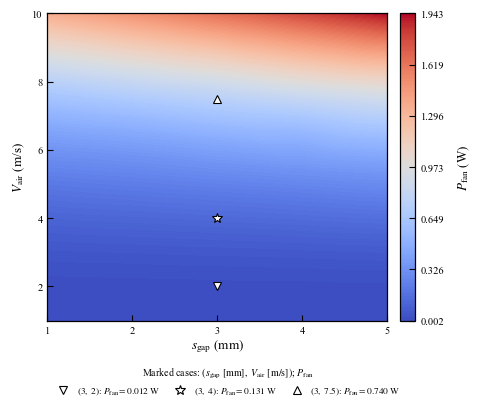

In [4]:
# Select one inlet-temperature slice because fan power is independent
# of the inlet air temperature.
power_data = plot_data[
    plot_data['T_air_in_C'] == 20.0
]

# Extract the variables used in the fan-power heatmap.
s_gap = power_data['s_gap_mm'].to_numpy()
v_air = power_data['V_air_m_s'].to_numpy()
p_fan = power_data['P_pump'].to_numpy()

# Create a dense grid to obtain a smooth heatmap.
s_gap_dense = np.linspace(
    s_gap.min(),
    s_gap.max(),
    350,
)

v_air_dense = np.linspace(
    v_air.min(),
    v_air.max(),
    350,
)

s_gap_grid, v_air_grid = np.meshgrid(
    s_gap_dense,
    v_air_dense,
)

# Interpolate the discrete fan-power results onto the dense grid.
p_fan_grid = griddata(
    (s_gap, v_air),
    p_fan,
    (s_gap_grid, v_air_grid),
    method='cubic',
)

# Define the common color range.
p_fan_min = p_fan.min()
p_fan_max = p_fan.max()

# Avoid small interpolation overshoots outside the original data range.
p_fan_grid = np.clip(
    p_fan_grid,
    p_fan_min,
    p_fan_max,
)

p_fan_levels = np.linspace(
    p_fan_min,
    p_fan_max,
    128,
)

# Create the fan-power heatmap.
figure, axis = plt.subplots(
    figsize=(4.80, 4.55)
)

heatmap = axis.contourf(
    s_gap_grid,
    v_air_grid,
    p_fan_grid,
    levels=p_fan_levels,
    cmap='coolwarm',
    antialiased=False,
)

# Mark the cases used in the fan-power discussion and build their legend.
# Figure 2 reports only the variables represented in this heatmap:
# cell spacing, inlet air velocity, and fan auxiliary power.
power_marker_settings = [
    {
        'gap': 3.0, 'velocity': 2.0,
        'marker': 'v', 'size': 5.2,
    },
    {
        'gap': 3.0, 'velocity': 4.0,
        'marker': '*', 'size': 7.4,
    },
    {
        'gap': 3.0, 'velocity': 7.5,
        'marker': '^', 'size': 5.2,
    },
]

power_legend_handles = []
power_legend_labels = []

for setting in power_marker_settings:
    gap_value = setting['gap']
    velocity = setting['velocity']

    axis.plot(
        gap_value,
        velocity,
        marker=setting['marker'],
        markersize=setting['size'],
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=0.8,
        linestyle='none',
        clip_on=False,
        zorder=10,
    )

    case_mask = (
        np.isclose(power_data['s_gap_mm'], gap_value)
        & np.isclose(power_data['V_air_m_s'], velocity)
    )
    case_rows = power_data.loc[case_mask]

    if case_rows.empty:
        power_text = r'$P_{\mathrm{fan}}$ unavailable'
    else:
        power_value = float(case_rows.iloc[0]['P_pump'])
        power_text = rf'$P_{{\mathrm{{fan}}}}={power_value:.3f}$ W'

    power_legend_handles.append(
        Line2D(
            [0],
            [0],
            marker=setting['marker'],
            markersize=setting['size'],
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=0.8,
            linestyle='none',
        )
    )

    power_legend_labels.append(
        rf'$({gap_value:g},\ {velocity:g})$: ' + power_text
    )

# Set the coordinate ranges and ticks.
axis.set_xlim(1, 5)
axis.set_ylim(1, 10)

axis.set_xticks([1, 2, 3, 4, 5])
axis.set_yticks([2, 4, 6, 8, 10])

axis.set_xlabel(
    r'$s_{\mathrm{gap}}$ (mm)',
    labelpad=1.0,
)

axis.set_ylabel(
    r'$V_{\mathrm{air}}$ (m/s)'
)

# Add the color bar for fan auxiliary power.
colorbar_ticks = np.linspace(
    p_fan_min,
    p_fan_max,
    7,
)

colorbar = figure.colorbar(
    heatmap,
    ax=axis,
    ticks=colorbar_ticks,
    pad=0.035,
    fraction=0.052,
)

colorbar.set_label(
    r'$P_{\mathrm{fan}}$ (W)',
    labelpad=8,
)

colorbar.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.3f')
)

colorbar.outline.set_linewidth(0.9)

# Put the marker legend below the fan-power heatmap.
# The expression follows Fig. 1, but uses only the variables relevant to Fig. 2.
figure.subplots_adjust(bottom=0.205)
figure.legend(
    power_legend_handles,
    power_legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.50, 0.018),
    ncol=3,
    frameon=False,
    title=(
        r'Marked cases: '
        r'$(s_{\mathrm{gap}}\ [\mathrm{mm}],\ '
        r'V_{\mathrm{air}}\ [\mathrm{m/s}])$; '
        r'$P_{\mathrm{fan}}$'
    ),
    title_fontsize=7.2,
    fontsize=6.7,
    handletextpad=0.45,
    columnspacing=1.10,
    labelspacing=0.50,
)

plt.show()


In [5]:
from pathlib import Path


# Define the program name and create the output folder.

output_dir = OUTPUT_DIR
os.makedirs(output_dir, exist_ok=True)
program_name = 'C0004R01_PARK25_AC_1D_SCAN_plot'

# Define the output file names.
fig1_file = os.path.join(output_dir, f'{program_name}_Fig01_Tmax_DeltaTmax_heatmaps.png')
fig2_file = os.path.join(output_dir, f'{program_name}_Fig02_Pfan.png')

# Save the combined heatmap figure and the fan-power heatmap.
fig_heatmaps.savefig(
    fig1_file,
    dpi=900,
    bbox_inches='tight',
    facecolor='white',
)

figure.savefig(
    fig2_file,
    dpi=900,
    bbox_inches='tight',
    facecolor='white',
)

# Display the saved file paths.
print(f'Figure 1 saved to: {fig1_file}')
print(f'Figure 2 saved to: {fig2_file}')


Figure 1 saved to: d:\Users\liu\Desktop\论文初阶段\eBATS_整合新程序未校核\out\C0004\C0004R01_PARK25_AC_1D_SCAN_plot_Fig01_Tmax_DeltaTmax_heatmaps.png
Figure 2 saved to: d:\Users\liu\Desktop\论文初阶段\eBATS_整合新程序未校核\out\C0004\C0004R01_PARK25_AC_1D_SCAN_plot_Fig02_Pfan.png
